<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/02-PyTorch-Computer-Vision/01_food101_mlp_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
from torch import nn
from torch.utils.data import Dataset , DataLoader
import torchvision
from torchvision import transforms
from torchvision import datasets

In [13]:
data_transform=transforms.Compose([
                                   transforms.Resize((224,224)),
                                  #  transforms.CenterCrop(10),
                                   transforms.RandomHorizontalFlip(p=0.5),
                                   transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.1,hue=0.1),
                                   transforms.ToTensor()
                                   ])

train_dataset=torchvision.datasets.Food101(
                                           root='./data',
                                           split='train',
                                           download=True,
                                           transform=data_transform
                                           )
test_dataset=torchvision.datasets.Food101(
                                           root='./data',
                                           split='test',
                                           download=True,
                                           transform=data_transform
                                           )

In [14]:
train_dataset,test_dataset

(Dataset Food101
     Number of datapoints: 75750
     Root location: ./data
     split=train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=(-0.1, 0.1))
                ToTensor()
            ),
 Dataset Food101
     Number of datapoints: 25250
     Root location: ./data
     split=test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=(-0.1, 0.1))
                ToTensor()
            ))

In [15]:
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


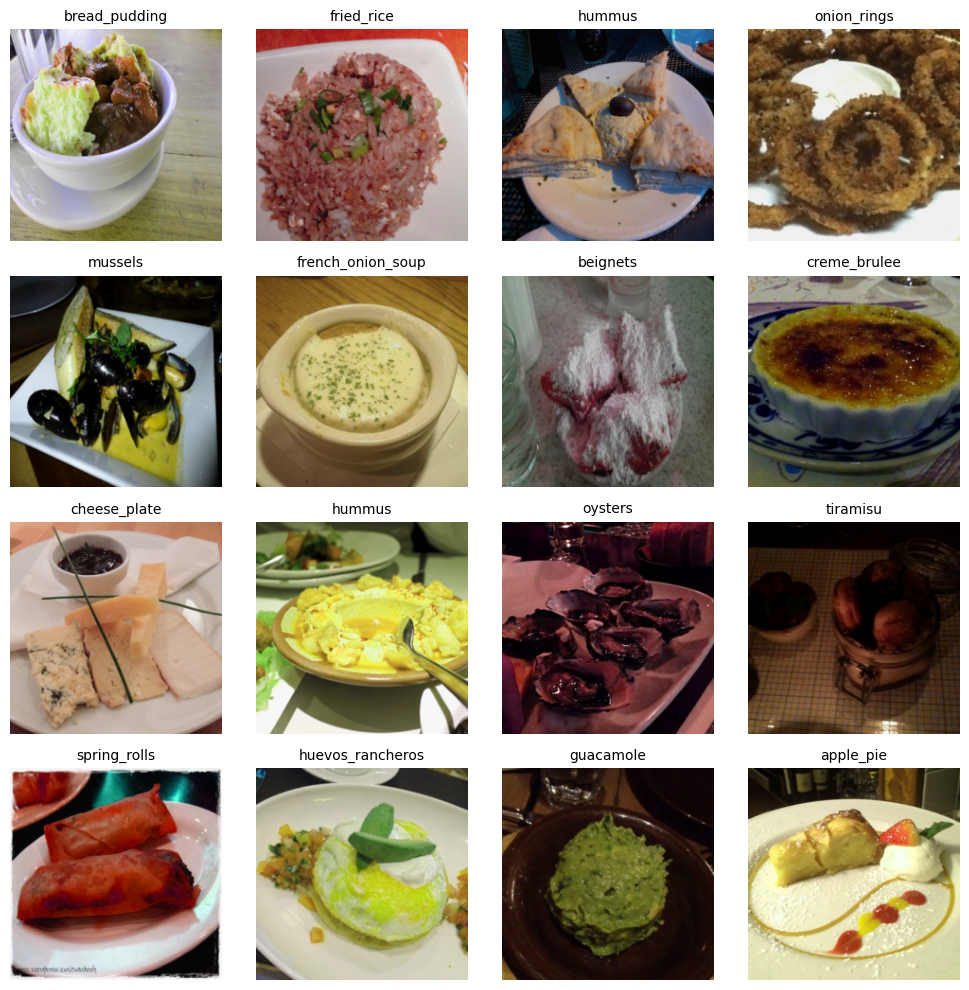

In [16]:
plt.figure(figsize=(10,10))
for i in range (16):
  idx=random.randint(0,len(train_dataset)-1)
  img,label=train_dataset[idx]
  class_name=train_dataset.classes[label]

  plt.subplot(4,4,i+1)
  plt.imshow(img.permute(1,2,0))              #Pytorch uses [C,H,W] While Matplotlib uses [H,W,C]
  plt.title(class_name, fontsize=10)
  plt.axis('off')

plt.tight_layout()   #Adjusts spacing
plt.show()

In [17]:
BATCH_SIZE=32

train_datalodear=DataLoader(
                            dataset=train_dataset,
                            batch_size=BATCH_SIZE,
                            num_workers=2,
                            pin_memory=True,
                            shuffle=True
                            )
test_datalodear=DataLoader(
                           dataset=test_dataset,
                           batch_size=BATCH_SIZE,
                           num_workers=2,
                           pin_memory=True,
                           shuffle=False
                           )

train_datalodear,test_datalodear

(<torch.utils.data.dataloader.DataLoader at 0x787d3dcc22c0>,
 <torch.utils.data.dataloader.DataLoader at 0x787d3dcc1f30>)

In [18]:
img_batch,label_batch=next(iter(train_datalodear))
img_batch.shape,label_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

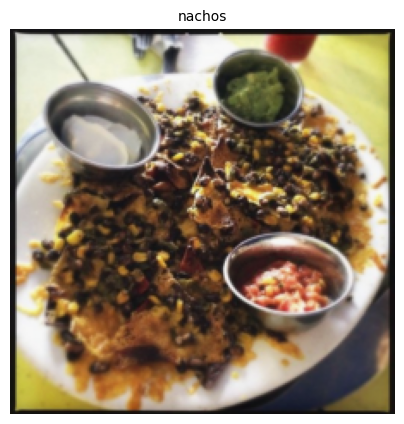

In [19]:
plt.figure(figsize=(5,5))

idx=random.randint(0,len(img_batch)-1)
img,label=img_batch[idx] , label_batch[idx]
class_name=train_dataset.classes[label]

plt.imshow(img.permute(1,2,0))
plt.title(class_name, fontsize=10)
plt.axis('off')
plt.show()

In [20]:
class food101modelv1(nn.Module):
  def __init__(
               self,
               input_shape: int,
               hidden_layer: int,
               output_shape: int
               ):
    super().__init__()
    layer_stack=nn.Sequential(
                              nn.Flatten(),
                              nn.Linear(
                                        in_features=input_shape,
                                        out_features=hidden_layer
                                        ),
                              nn.ReLU(),
                              nn.Linear(in_features=hidden_layer,
                                        out_features=hidden_layer),
                              nn.ReLU(),
                              nn.Linear(in_features=hidden_layer,
                                        out_features=hidden_layer),
                              nn.ReLU(),
                              nn.Linear(in_features=hidden_layer,
                                        out_features=output_shape)
                              )
    self.layer_stack=layer_stack

  def forward(self,x):
    return self.layer_stack(x)


model_1=food101modelv1(
                        input_shape=3*224*224,
                        hidden_layer=64,
                        output_shape=101
                        ).to(device)

model_1

food101modelv1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=101, bias=True)
  )
)

In [21]:
!pip install torchmetrics
import torchmetrics

loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(params=model_1.parameters(),lr=0.001)

accuracy_fn=torchmetrics.Accuracy(task='multiclass',num_classes=101).to(device)

In [22]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [23]:
from tqdm.auto import tqdm
import torch
from torch.utils.data import Subset

# Using only 10% of the data for rapid experimentation
train_subset_indices = torch.randperm(len(train_dataset))[:len(train_dataset)//10]
train_subset = Subset(train_dataset, train_subset_indices)

exp_train_datalodear = DataLoader(
    dataset=train_subset,
    batch_size=64,
    num_workers=2,
    pin_memory=True,
    shuffle=True
)


timer_start=timer()
epochs=5

for epochs in tqdm(range(epochs)):
  train_loss=0
  train_acc=0
  for batch , (image_batch,label_batch) in enumerate(exp_train_datalodear):
    image_batch,label_batch=image_batch.to(device),label_batch.to(device)

    model_1.train()

    y_pred=model_1(image_batch)

    loss=loss_fn(y_pred,label_batch)
    train_loss+=loss
    train_acc+=accuracy_fn(y_pred.argmax(dim=1),label_batch)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch % 50 == 0:
      print(f"Looked at {batch * len(image_batch)}/{len(exp_train_datalodear.dataset)} samples")

  avg_train_loss=train_loss/len(exp_train_datalodear)
  avg_train_acc=train_acc/len(exp_train_datalodear)
  print(f"Epochs: {epochs} | Train Loss: {avg_train_loss} | Train Accuracy: {avg_train_acc}")

timer_end=timer()
print_train_time(timer_start,timer_end,device)

  0%|          | 0/5 [00:00<?, ?it/s]

Looked at 0/7575 samples
Looked at 3200/7575 samples
Looked at 6400/7575 samples
Epochs: 0 | Train Loss: 4.7926554679870605 | Train Accuracy: 0.010635504499077797
Looked at 0/7575 samples
Looked at 3200/7575 samples
Looked at 6400/7575 samples
Epochs: 1 | Train Loss: 4.616185665130615 | Train Accuracy: 0.011292017064988613
Looked at 0/7575 samples
Looked at 3200/7575 samples
Looked at 6400/7575 samples
Epochs: 2 | Train Loss: 4.615848541259766 | Train Accuracy: 0.01155462209135294
Looked at 0/7575 samples
Looked at 3200/7575 samples
Looked at 6400/7575 samples
Epochs: 3 | Train Loss: 4.615046977996826 | Train Accuracy: 0.01155462209135294
Looked at 0/7575 samples
Looked at 3200/7575 samples
Looked at 6400/7575 samples
Epochs: 4 | Train Loss: 4.614254951477051 | Train Accuracy: 0.01155462209135294
Train time on cuda: 348.246 seconds


348.24560952599995

##  The Need for Convolutional Neural Networks (CNNs)

**Observation:**
* A standard Multi-Layer Perceptron (MLP) without non-linear activations (`ReLU`) yielded an accuracy of ~4%.
* Adding non-linear activations (`ReLU`) only marginally improved accuracy to ~11%.

**Conclusion:**
Standard MLP architectures perform poorly on complex Computer Vision tasks. Using `nn.Flatten()` converts a 2D image matrix into a 1D vector. This destroys crucial spatial information, meaning the model loses the ability to recognize shapes, edges, curves, and the relationship between neighboring pixels. To solve this, we must use architectures that preserve 2D spatial features.